In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data read
df=pd.read_excel(r"C:\Users\shash\Downloads\Dataset for DATA_ANALYST\archive (2)\walmart.xlsx")

In [3]:
df.head()

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
0,CA-2013-138688,2013-06-13,2013-06-17,Darrin Van Huff,United States,Los Angeles,California,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714
1,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694
2,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Art,Newell 322,7.280,4,1.9656
3,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152
4,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825


In [4]:
df.shape

(3203, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   Customer Name  3203 non-null   object        
 4   Country        3203 non-null   object        
 5   City           3203 non-null   object        
 6   State          3203 non-null   object        
 7   Category       3203 non-null   object        
 8   Product Name   3203 non-null   object        
 9   Sales          3203 non-null   float64       
 10  Quantity       3203 non-null   int64         
 11  Profit         3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 300.4+ KB


In [6]:
df.describe

<bound method NDFrame.describe of             Order ID Order Date  Ship Date    Customer Name        Country  \
0     CA-2013-138688 2013-06-13 2013-06-17  Darrin Van Huff  United States   
1     CA-2011-115812 2011-06-09 2011-06-14  Brosina Hoffman  United States   
2     CA-2011-115812 2011-06-09 2011-06-14  Brosina Hoffman  United States   
3     CA-2011-115812 2011-06-09 2011-06-14  Brosina Hoffman  United States   
4     CA-2011-115812 2011-06-09 2011-06-14  Brosina Hoffman  United States   
...              ...        ...        ...              ...            ...   
3198  CA-2013-125794 2013-09-30 2013-10-04     Maris LaWare  United States   
3199  CA-2014-121258 2014-02-27 2014-03-04      Dave Brooks  United States   
3200  CA-2014-121258 2014-02-27 2014-03-04      Dave Brooks  United States   
3201  CA-2014-121258 2014-02-27 2014-03-04      Dave Brooks  United States   
3202  CA-2014-119914 2014-05-05 2014-05-10     Chris Cortes  United States   

             City       State

In [7]:
# missing value
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
Customer Name    0
Country          0
City             0
State            0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df[df.duplicated()]

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit


In [10]:
# convert date datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df.dtypes

Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Customer Name            object
Country                  object
City                     object
State                    object
Category                 object
Product Name             object
Sales                   float64
Quantity                  int64
Profit                  float64
dtype: object

In [12]:
# Correct Quantity type
df['Quantity'] = df['Quantity'].astype(int)

In [13]:
# Clean text
df[df['Product Name'].str.contains('Â', na=False)]

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit
7,CA-2011-115812,2011-06-09,2011-06-14,Brosina Hoffman,United States,Los Angeles,California,Phones,Konftel 250 ConferenceÂ phoneÂ - Charcoal black,911.424,4,68.3568
15,CA-2013-121755,2013-01-16,2013-01-20,Eric Hoffmann,United States,Los Angeles,California,Accessories,ImationÂ 8GB Mini TravelDrive USB 2.0Â Flash D...,90.570,3,11.7741
50,CA-2013-158834,2013-03-14,2013-03-17,Tamara Willingham,United States,Scottsdale,Arizona,Phones,Jabra BIZ 2300 Duo QD Duo CordedÂ Headset,203.184,2,15.2388
59,CA-2011-118962,2011-08-05,2011-08-09,Chad Sievert,United States,Los Angeles,California,Paper,"Adams Phone Message Book, Professional, 400 Me...",20.940,3,9.8418
72,CA-2013-145625,2013-09-12,2013-09-18,Kelly Collister,United States,San Diego,California,Accessories,LogitechÂ P710e Mobile Speakerphone,3347.370,13,636.0003
...,...,...,...,...,...,...,...,...,...,...,...,...
3008,CA-2014-102820,2014-05-08,2014-05-12,Carlos Soltero,United States,Pasadena,California,Phones,Blue Parrot B250XT Professional Grade Wireless...,419.944,7,52.4930
3022,CA-2011-145254,2011-07-23,2011-07-27,Nick Crebassa,United States,San Francisco,California,Accessories,ImationÂ 8gb Micro Traveldrive Usb 2.0Â Flash ...,45.000,3,4.9500
3024,CA-2012-119627,2012-08-17,2012-08-23,Steven Cartwright,United States,Peoria,Arizona,Accessories,ImationÂ Clip USBÂ flash driveÂ - 8 GB,30.080,2,-5.2640
3064,CA-2014-104619,2014-01-25,2014-01-30,Keith Dawkins,United States,San Jose,California,Phones,Jensen SMPS-640 -Â speaker phone,110.352,3,8.2764


In [14]:
# Feature 
df['Product Name'] = (
    df['Product Name']
    .str.replace('Â', '', regex=False)
    .str.strip()
)

In [15]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [16]:
df[df['Shipping Days'] < 0]

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Shipping Days


In [17]:
df[df['Sales'] <= 0]

,Order ID,Order Date,Ship Date,Customer Name,Country,City,State,Category,Product Name,Sales,Quantity,Profit,Shipping Days


In [18]:
loss = df[df['Profit'] < 0]

In [19]:
profit = df[df['Profit'] > 0]

# BoxPlot implement

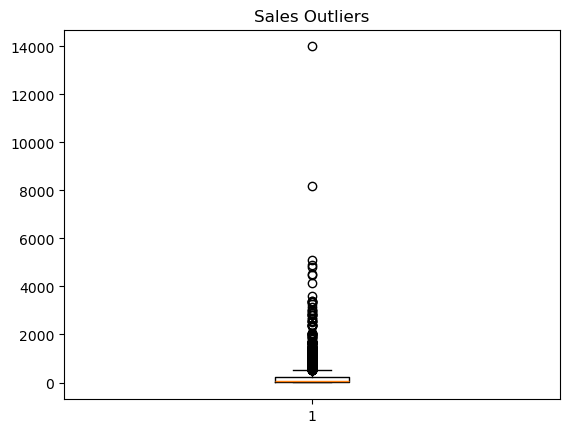

In [20]:
import matplotlib.pyplot as plt

plt.boxplot(df['Sales'])
plt.title('Sales Outliers')
plt.show()

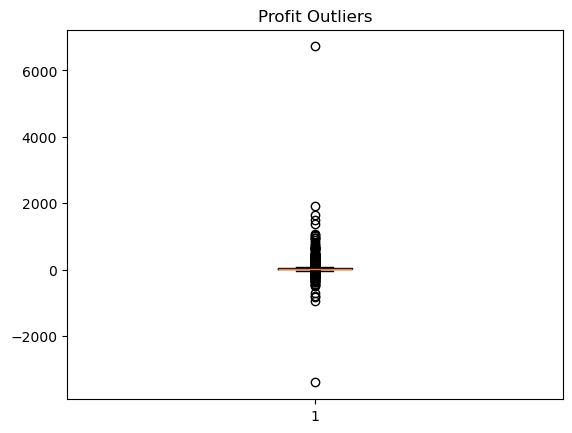

In [21]:
# For Profit
plt.boxplot(df['Profit'])
plt.title('Profit Outliers')
plt.show()

In [22]:
df['Country'].nunique()

1

In [23]:
df.drop(columns=['Country'], inplace=True)

In [24]:
df['Year'] = df['Order Date'].dt.year

In [25]:
df['Month'] = df['Order Date'].dt.month

In [26]:
df['Shipping Days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [27]:
df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

In [28]:
df['Status'] = df['Profit'].apply(
    lambda x: 'Profit' if x > 0
    else 'Loss' if x < 0
    else 'No Profit No Loss'
)

In [29]:
df['Status'].value_counts()

Status
Profit               2863
Loss                  318
No Profit No Loss      22
Name: count, dtype: int64

In [30]:
df['Sales'].sum()

np.float64(725457.8245)

In [31]:
df['Profit'].sum()

np.float64(108418.4489)

In [32]:
df['Order ID'].nunique()

1611

In [34]:
df['Customer Name'].nunique()

686

In [35]:
df['Quantity'].sum()

np.int64(12264)

In [36]:
df.groupby('State')['Sales'].sum().sort_values(
    ascending=False
)

State
California    457687.6315
Washington    138641.2700
Arizona        35282.0010
Colorado       32108.1180
Oregon         17431.1500
Nevada         16729.1020
Utah           11220.0560
Montana         5589.3520
New Mexico      4783.5220
Idaho           4382.4860
Wyoming         1603.1360
Name: Sales, dtype: float64

In [37]:
df.groupby('State')['Profit'].sum().sort_values(
    ascending=False
)

State
California    76381.3871
Washington    33402.6517
Nevada         3316.7659
Utah           2546.5335
Montana        1833.3285
New Mexico     1157.1161
Idaho           826.7231
Wyoming         100.1960
Oregon        -1190.4705
Arizona       -3427.9246
Colorado      -6527.8579
Name: Profit, dtype: float64

In [38]:
df.groupby('Category')['Sales'].sum().sort_values(
    ascending=False
)

Category
Chairs         101781.3280
Phones          98684.3520
Tables          84754.5620
Storage         70532.8520
Accessories     61114.1160
Binders         55961.1130
Copiers         49749.2420
Machines        42444.1220
Bookcases       36004.1235
Appliances      30236.3360
Furnishings     30072.7300
Paper           26663.7180
Supplies        18127.1220
Art              9212.0660
Labels           5078.7260
Envelopes        4118.1000
Fasteners         923.2160
Name: Sales, dtype: float64

In [39]:
df.groupby('Category')['Profit'].sum().sort_values(
    ascending=False
)

Category
Copiers        19327.2351
Accessories    16484.5983
Binders        16096.8016
Paper          12119.2364
Phones          9110.7426
Storage         8645.3222
Appliances      8261.2699
Furnishings     7641.2704
Chairs          4027.5843
Art             2374.0970
Labels          2303.1223
Envelopes       1908.7624
Tables          1482.6073
Supplies         626.0465
Fasteners        275.1907
Machines        -618.9264
Bookcases      -1646.5117
Name: Profit, dtype: float64

In [40]:
df.groupby('Year')['Sales'].sum()

Year
2011    147883.0330
2012    139966.2495
2013    186976.0165
2014    250632.5255
Name: Sales, dtype: float64

In [41]:
df.groupby('Month')['Sales'].sum()

Month
1      24918.6190
2      16268.6150
3      73023.7390
4      41966.5850
5      45320.8745
6      48519.5455
7      64706.8940
8      62674.3280
9      81618.4605
10     57436.7980
11     93068.8225
12    115934.5435
Name: Sales, dtype: float64

In [42]:
df.groupby('Product Name')['Sales'].sum() \
  .sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          13999.960
High Speed Automatic Electric Letter Opener                                    13100.240
Global Troy Executive Leather Low-Back Tilter                                  10019.600
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     8134.336
GuestStacker Chair with Chrome Finish Legs                                      8030.016
Okidata MB760 Printer                                                           7834.400
Bretford Rectangular Conference Table Tops                                      7710.665
Logitech P710e Mobile Speakerphone                                              7467.210
Canon PC1060 Personal Laser Copier                                              6719.904
Hewlett Packard LaserJet 3310 Copier                                            6239.896
Name: Sales, dtype: float64

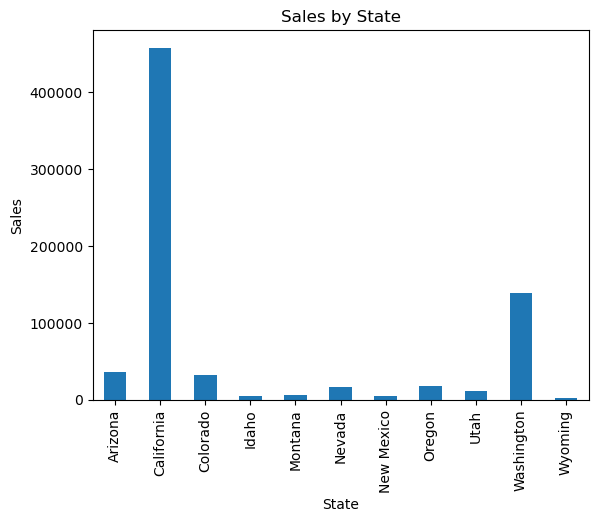

In [43]:
import matplotlib.pyplot as plt

df.groupby('State')['Sales'].sum().plot(
    kind='bar'
)

plt.title('Sales by State')
plt.ylabel('Sales')
plt.show()

In [44]:
df.to_csv("walmart_cleaned.csv", index=False)

In [45]:
import os

print(os.getcwd())

C:\Users\shash\Data Analyst
